### The patterns you need

In [1]:
# sns.scatterplot(data=df, x='col', y='col')             # one measurement against another
# sns.histplot(data=df, x='col')                         # the distribution of one column
# sns.barplot(x=series.values, y=series.index)           # a grouped Series, as bars

# hue='col'                                              # works on all three

In [2]:
# plt.figure(figsize=(w, h))
# plt.xlabel(...) ; plt.ylabel(...) ; plt.title(...)
# plt.tight_layout()

In [3]:
# df.dropna()
# df.groupby('key')['column'].agg(['count', 'mean'])
# df['column'].value_counts()
# df.sort_values('column', ascending=False)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://eds-217-essential-python.github.io/data/penguins.csv'
penguins = pd.read_csv(url)
penguins.shape

(344, 7)

In [5]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [6]:
penguins['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [7]:
penguins['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

In [8]:
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [9]:
birds = penguins.dropna()
birds.shape
# Lost 11 rows

(333, 7)

In [10]:
birds['species'].value_counts()
# Lost some Adelie and Gentoos

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

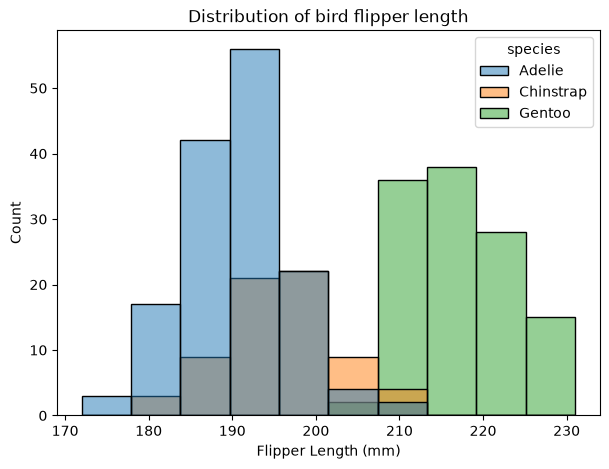

In [11]:
plt.figure(figsize=(7, 5))

sns.histplot(data=birds, x='flipper_length_mm', hue= 'species')

plt.xlabel('Flipper Length (mm)')
plt.title('Distribution of bird flipper length')
plt.show()

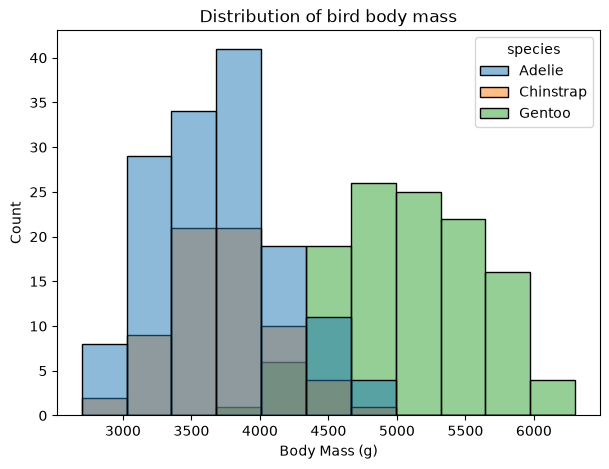

In [12]:
plt.figure(figsize=(7, 5))

sns.histplot(data=birds, x='body_mass_g', hue= 'species')

plt.xlabel('Body Mass (g)')
plt.title('Distribution of bird body mass')
plt.show()

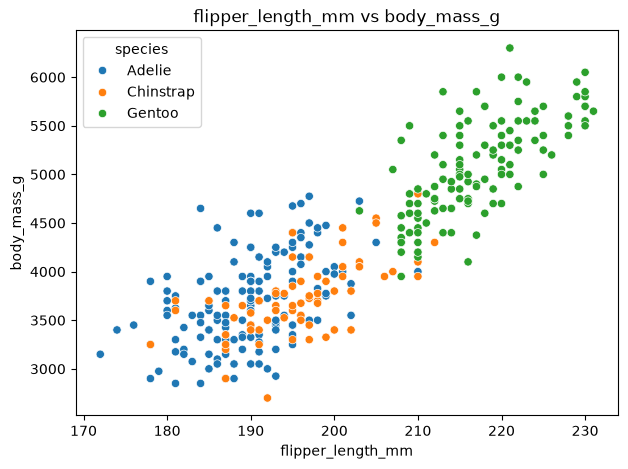

In [13]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=penguins,
     x='flipper_length_mm',
      y='body_mass_g',
       hue='species')

plt.xlabel('flipper_length_mm')
plt.ylabel('body_mass_g')
plt.title('flipper_length_mm vs body_mass_g')
plt.show()

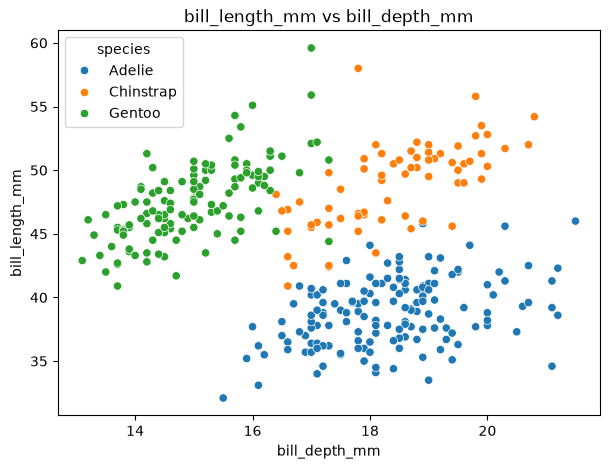

In [14]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=penguins,
     x='bill_depth_mm',
      y='bill_length_mm',
       hue='species')

plt.xlabel('bill_depth_mm')
plt.ylabel('bill_length_mm')
plt.title('bill_length_mm vs bill_depth_mm')
plt.show()

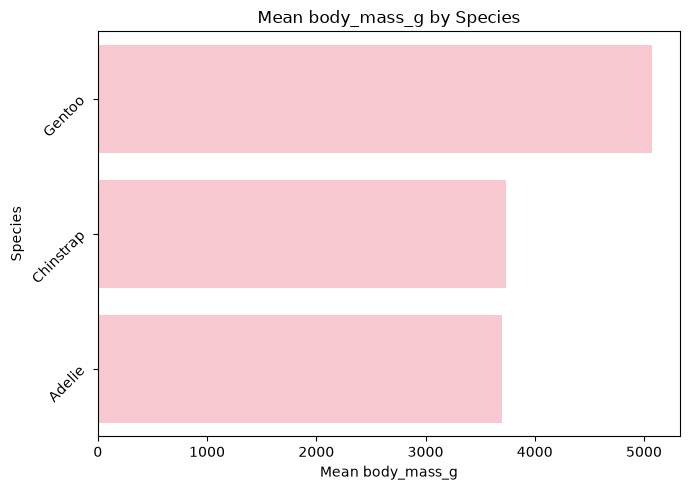

Chinstrap and Adelie are similar birds.


In [15]:
# manual calc of means
# group, aggregate, sort
# then plot the .values against the .index.

mean_peng = penguins.groupby('species')[
    'body_mass_g'].mean(
    ).sort_values(ascending=False)

plt.figure(figsize=(7, 5))

sns.barplot(x=mean_peng.values, y=mean_peng.index, color='pink')

plt.yticks(rotation=45)
plt.xlabel('Mean body_mass_g')
plt.ylabel('Species')
plt.title('Mean body_mass_g by Species')
plt.tight_layout()
plt.show()
print("Chinstrap and Adelie are similar birds.")

In [16]:
agg_peng = penguins.groupby('species')[
    'body_mass_g'].agg(['count', 'mean'])
agg_peng

,count,mean
species,,
Adelie,151,3700.662252
Chinstrap,68,3733.088235
Gentoo,123,5076.016260


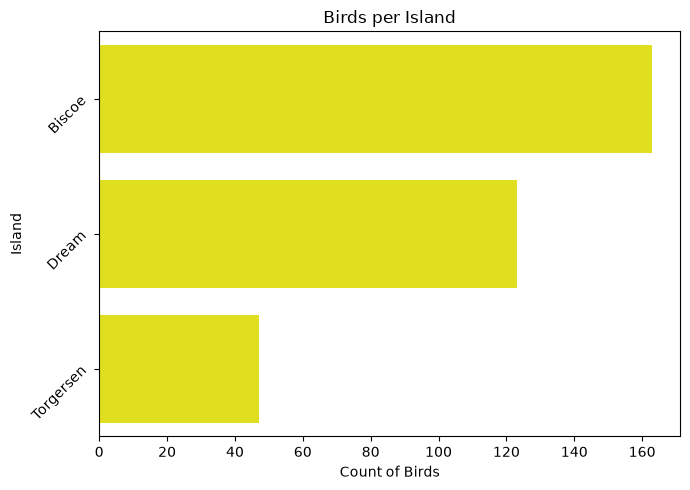

In [17]:
series = birds['island'].value_counts()
series

plt.figure(figsize=(7, 5))

sns.barplot(x=series.values, y=series.index, color='yellow')

plt.yticks(rotation=45)
plt.xlabel('Count of Birds')
plt.ylabel('Island')
plt.title('Birds per Island')
plt.tight_layout()
plt.show()

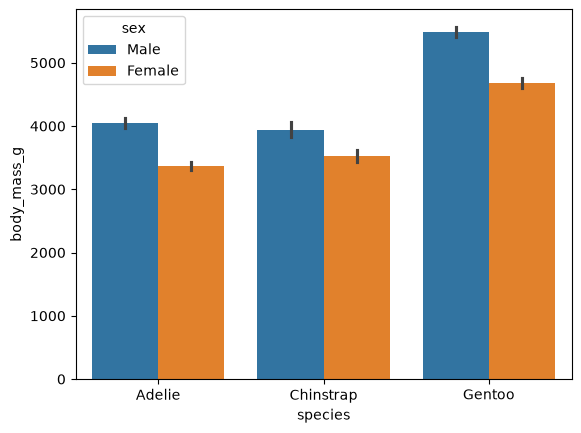

In [18]:
sns.barplot(data=birds, x='species', y='body_mass_g', hue='sex')

plt.show()

In [19]:
pivot_birds = birds.pivot_table(
    index='species',
    columns='island',
    values='body_mass_g',
    aggfunc='count'
)
print(pivot_birds)
print('Pivot shows some species of penguins are not on all islands.')

island     Biscoe  Dream  Torgersen
species                            
Adelie       44.0   55.0       47.0
Chinstrap     NaN   68.0        NaN
Gentoo      119.0    NaN        NaN
Pivot shows some species of penguins are not on all islands.
